In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.dimensionality import BaseDimensionalityReduction
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
import torch
from wordcloud import WordCloud

f:\UI\Semester 8\Tugas Akhir\topic-modelling\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
indo_stopwords = [
    # Basic Indonesian stopwords (keep these)
    "yang", "dan", "di", "dengan", "untuk", "dari", "ke", "pada", "ini", "itu",
    "atau", "ada", "juga", "dalam", "saya", "kamu", "anda", "mereka", "kita", "kami",
    "dia", "nya", "adalah", "akan", "oleh", "seperti", "telah", "sudah", "bisa", "dapat",
    "tidak", "tak", "jangan", "ya", "via", "yg", "dgn", "utk", "dr", "pd", "dlm", "sdh", "tdk",
    "tapi", "aku","gini","begini", "kayak"
    
    # All candidate names and variations (since they appear everywhere)
    "anies", "baswedan", "rasyid", "muhaimin", "iskandar", "cak", "imin", "gus", 
    "prabowo", "subianto", "gibran", "rakabuming", "raka", "ganjar", "pranowo", 
    "mahfud", "md", "gama", "mawi", "abdurrahman", "abdul", "amin"
    
    # Titles and name prefixes
    "mas", "pak", "bu", "bapak", "ibu", "om", "tante", "mbak", "bro", "sis", "bang", 
    "abang", "kak", "adek", "adik", "kakak", "bung", "prof", "dr", "haji", "hajah", "h",
    
    # Social media expressions
    "rt", "dm", "pm", "cc", "wkwk", "haha", "woi", "hey", "ah", "eh", "oh", "hmm", "btw",
    "omg", "lol", "sih", "aja", "gitu", "banget", "kok", "deh", "ih", "yuk", "mantap",
    "insya", "insyaallah", "alhamdulillah", "bismillah", "amin", "allahuma", "allah",
    
    # Locations
    "jakarta", "jawa", "barat", "timur", "tengah", "utara", "selatan", "sumatra", "bali", 
    "aceh", "kota", "desa", "daerah", "wilayah", "provinsi", "kabupaten", "kawasan",
    "bandung", "surabaya", "makassar", "balikpapan", "semarang", "yogyakarta", "solo", "korea"
    
]

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [4]:
def run_topic_modeling(df, group_name='ALL'):
     # Set up custom vectorizer
    vectorizer = CountVectorizer(
        stop_words=indo_stopwords,
        ngram_range=(1, 3),
        min_df=5,
        max_df=0.7
    )

    # Set up UMAP
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )

    # Set up HDBSCAN
    hdbscan_model = HDBSCAN(
        min_cluster_size=10,
        min_samples=5,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    # Set up c-TF-IDF
    ctfidf_model = ClassTfidfTransformer(
        reduce_frequent_words=True,
        bm25_weighting=True
    )

    # Sentence embeddings
    embedding_model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

    # BERTopic setup
    topic_model = BERTopic(
        language="multilingual",
        calculate_probabilities=True,
        verbose=True,
        nr_topics=15,
        min_topic_size=5,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        ctfidf_model=ctfidf_model,
        vectorizer_model=vectorizer,
        embedding_model=embedding_model
    )

    # Fit model
    docs = df['full_text'].tolist()
    topics, probs = topic_model.fit_transform(docs)
    
    # Generate custom topic labels
    topic_labels = {}
    for topic_id in topic_model.get_topic_info()["Topic"]:
        if topic_id == -1:
            topic_labels[topic_id] = "outlier"
            continue
        words = [word for word, _ in topic_model.get_topic(topic_id)[:5]]
        if any(term in words for term in ["palestina", "doa", "israel", "gaza"]):
            topic_labels[topic_id] = "Kampanye & Isu Palestina"
        elif any(term in words for term in ["aceh", "warga", "sambut", "bandara", "kedatagan"]):
            topic_labels[topic_id] = "Kunjungan Kampanye Aceh"
        elif any(term in words for term in ["sumbar", "sumatra", "safari", "bukittinggi"]):
            topic_labels[topic_id] = "Kampanye Sumatra Barat"
        elif any(term in words for term in ["adil", "makmur", "sejahtera", "ekonomi"]):
            topic_labels[topic_id] = "Visi Ekonomi & Kemakmuran"
        elif any(term in words for term in ["amin", "bismillah", "islam", "muslim"]):
            topic_labels[topic_id] = "Dukungan Religius"
        elif any(term in words for term in ["pesantren", "santri", "kiai", "ulama"]):
            topic_labels[topic_id] = "Dukungan Pesantren"
        elif any(term in words for term in ["konstitusi", "mk", "etik", "putus"]):
            topic_labels[topic_id] = "Polemik Mahkamah Konstitusi"
        elif any(term in words for term in ["solo", "surakarta", "wali"]):
            topic_labels[topic_id] = "Kinerja di Solo"
        elif any(term in words for term in ["elektabilitas", "unggul", "menang", "putar"]):
            topic_labels[topic_id] = "Elektabilitas & Polling"
        elif any(term in words for term in ["joget", "pidato", "debat", "acara"]):
            topic_labels[topic_id] = "Penampilan Pidato & Debat"
        else:
            # Use top 3 words as label for other topics
            topic_labels[topic_id] = " & ".join(words[:3])
    topic_model.set_topic_labels(topic_labels)

    # Topic info
    topic_info = topic_model.get_topic_info()
    print(f"\nTopic Information for: {group_name}")
    print(topic_info.head(10))

    # Print topic summaries
    print(f"\nTopik Pembicaraan Masyarakat terhadap Calon Prabowo-Gibran ({group_name}):")
    for index, row in topic_info.iterrows():
        if row["Topic"] != -1:
            topic_id = row["Topic"]
            words = [word[0] for word in topic_model.get_topic(topic_id)[:8]]
            print(f"Theme: {row['Name']}")
            print(f"Keywords: {', '.join(words)}")
            print(f"Document count: {row['Count']}")
            print("-" * 50)

    # Bar chart of topic distribution
    plt.figure(figsize=(12, 6))
    topic_counts = topic_info[topic_info["Topic"] != -1]["Count"]
    topic_names = [topic_labels[topic] for topic in topic_info[topic_info["Topic"] != -1]["Topic"]]

    bars = plt.bar(topic_names, topic_counts, color=plt.cm.viridis(np.linspace(0, 1, len(topic_counts))))
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    plt.xticks(rotation=45, ha="right")
    plt.title(f"Distribusi Topik: {group_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Topik Pembicaraan", fontsize=12)
    plt.ylabel("Jumlah Tweet", fontsize=12)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Interactive Visualizations
    display(topic_model.visualize_topics())
    display(topic_model.visualize_hierarchy())
    display(topic_model.visualize_heatmap())

    # Word Clouds for top 3 topics
    plt.figure(figsize=(15, 10))
    for i, topic_id in enumerate(topic_info[topic_info['Topic'] != -1]['Topic'][:3]):
        plt.subplot(1, 3, i+1)
        words = dict(topic_model.get_topic(topic_id)[:15])
        wordcloud = WordCloud(width=400, height=400, background_color='white',
                              colormap='viridis', max_words=50).generate_from_frequencies(words)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"Topic: {topic_labels[topic_id]}", fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Representative sentences per topic
    print(f"\nKalimat Representatif untuk Setiap Topik ({group_name}):")
    rep_docs = topic_model.get_representative_docs()
    rows = []
    for topic_id, texts in rep_docs.items():
        if topic_id == -1:
            continue
        rows.append({
            "Topic ID": topic_id,
            "Label": topic_labels[topic_id],
            "Representative Sentence": texts[0]  # You can use texts[:3] for more
        })
    rep_df = pd.DataFrame(rows)
    display(rep_df)

    return topic_model, topics, probs

In [8]:
df_02 = pd.read_csv('data/02_full_context_pred.csv')

2025-05-26 16:42:13,012 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 764/764 [06:06<00:00,  2.08it/s]
2025-05-26 16:48:20,007 - BERTopic - Embedding - Completed ✓
2025-05-26 16:48:20,008 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 16:48:36,501 - BERTopic - Dimensionality - Completed ✓
2025-05-26 16:48:36,503 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 16:53:37,167 - BERTopic - Cluster - Completed ✓
2025-05-26 16:53:37,168 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 16:53:38,488 - BERTopic - Representation - Completed ✓
2025-05-26 16:53:38,489 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 16:53:38,517 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 16:53:39,551 - BERTopic - Representation - Completed ✓
2025-05-26 16:53:39,554 - BERTopic - Topic reduction - Re


Topic Information for: POSITIVE
   Topic  Count                                               Name  \
0     -1   8206                       -1_anies_jokowi_pilih_karena   
1      0   5888  0_menang satu_pilpres_putaran_menang satu putaran   
2      1   4128           1_02 menang_pendukung 02_in 02_all in 02   
3      2   3031                       2_debat_politik_survey_video   
4      3    978             3_presiden_jadi presiden_demokrasi_ahy   
5      4    815  4_wakil presiden_wakil_calon presiden_calon wa...   
6      5    555                 5_program_gratis_makan_makan siang   
7      6    319                     6_pagi_selamat pagi_salam_dong   
8      7    188  7_positif_perubahan positif_membawa perubahan_...   
9      8    134    8_ekonomi_pertumbuhan_infrastruktur_menciptakan   

                                        CustomName  \
0                                          outlier   
1                  menang satu & pilpres & putaran   
2                 02 menang & pend

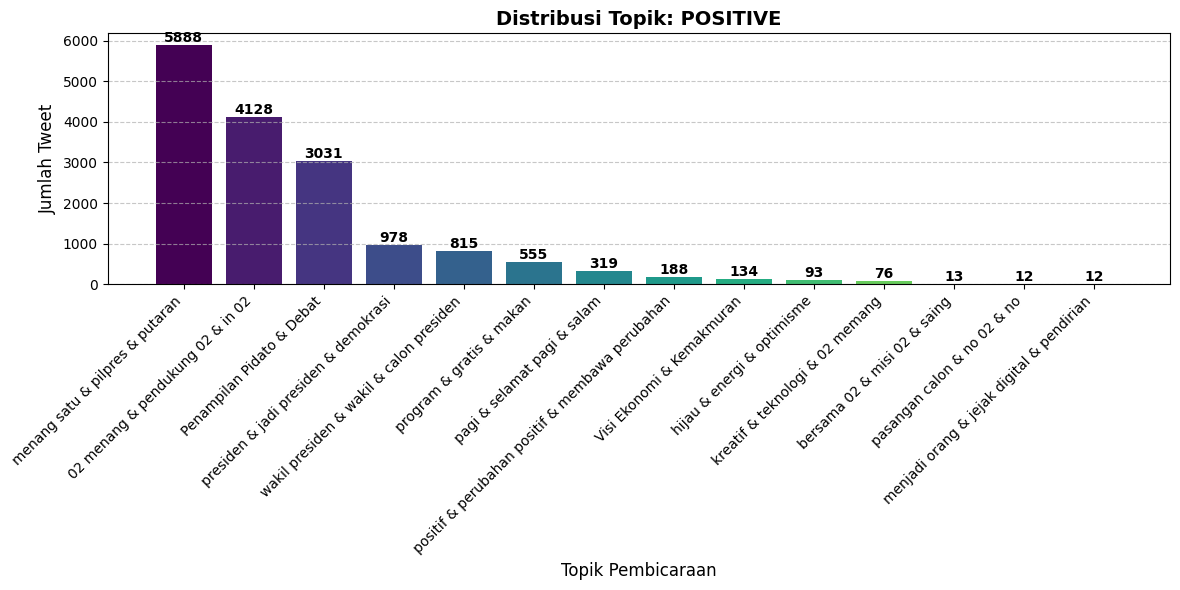

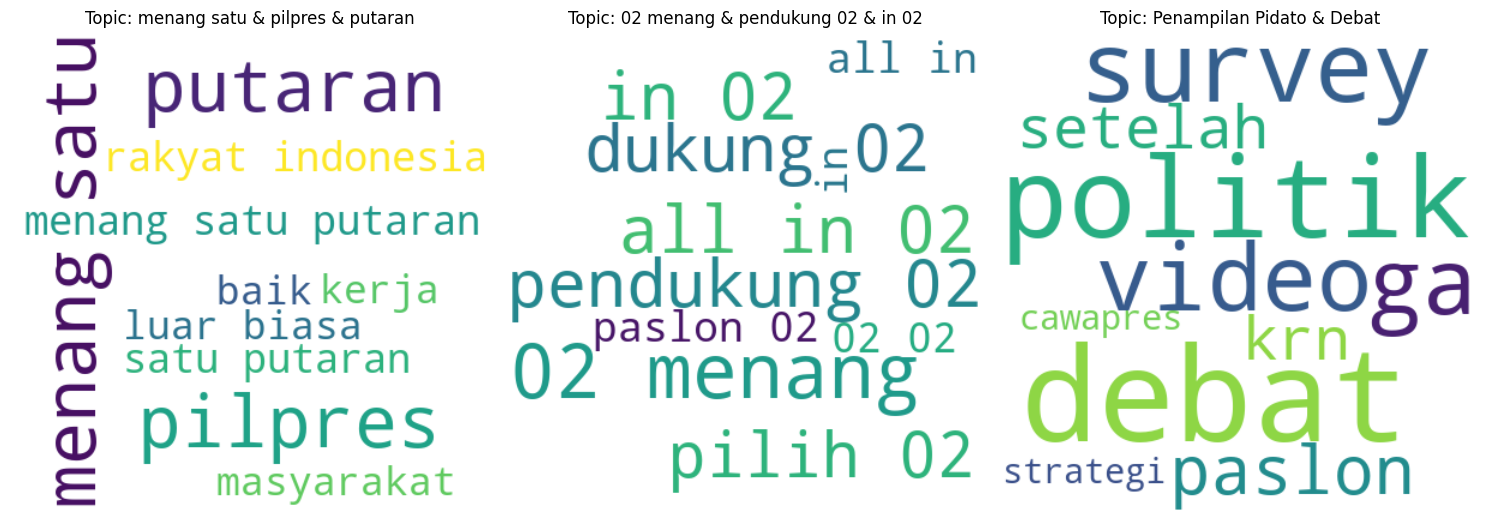


Kalimat Representatif untuk Setiap Topik (POSITIVE):


,Topic ID,Label,Representative Sentence
0,0,menang satu & pilpres & putaran,sosok pemimpin yang baik berjiwa patriotik leb...
1,1,02 menang & pendukung 02 & in 02,peduli setan yang penting bowo gemoy gua all i...
2,2,Penampilan Pidato & Debat,penilaian pengamat tentang debat capres tahap ...
3,3,presiden & jadi presiden & demokrasi,menghambat prabowo jadi presiden itu hak demok...
4,4,wakil presiden & wakil & calon presiden,tim kampanye nasional tkn prabowo subianto gib...
5,5,program & gratis & makan,tahu gak keunggulan calon wakil presiden gibra...
6,6,pagi & selamat pagi & salam,prabowo selamat pagi amin
7,7,positif & perubahan positif & membawa perubahan,prabowo gibran dipandang sebagai pasangan yang...
8,8,Visi Ekonomi & Kemakmuran,prabowo sepakat harapan pakprabowo masgibran m...
9,9,hijau & energi & optimisme,optimisme gibran soal energi hijau bikin kita ...


(<bertopic._bertopic.BERTopic at 0x2a369245400>,
 [-1,
  0,
  0,
  4,
  -1,
  0,
  -1,
  6,
  0,
  0,
  -1,
  2,
  2,
  3,
  3,
  0,
  5,
  -1,
  2,
  0,
  -1,
  -1,
  0,
  3,
  0,
  0,
  0,
  0,
  6,
  -1,
  -1,
  0,
  0,
  0,
  0,
  0,
  -1,
  -1,
  -1,
  3,
  -1,
  0,
  0,
  0,
  -1,
  -1,
  -1,
  4,
  -1,
  5,
  -1,
  5,
  4,
  -1,
  4,
  -1,
  4,
  4,
  4,
  4,
  5,
  4,
  -1,
  5,
  0,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  -1,
  4,
  4,
  -1,
  -1,
  0,
  0,
  2,
  2,
  7,
  1,
  0,
  -1,
  0,
  -1,
  -1,
  4,
  4,
  8,
  4,
  -1,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  4,
  5,
  4,
  0,
  -1,
  4,
  4,
  4,
  4,
  3,
  0,
  0,
  -1,
  0,
  -1,
  -1,
  2,
  0,
  0,
  0,
  3,
  2,
  0,
  0,
  4,
  4,
  4,
  4,
  4,
  5,
  4,
  4,
  4,
  4,
  4,
  4,
  0,
  3,
  2,
  0,
  8,
  -1,
  1,
  4,
  4,
  6,
  -1,
  4,
  4,
  4,
  4,
  4,
  2,
  3,
  0,
  2,
  4,
  4,
  4,
  4,
  5,
  4,
  3,
  -1,
  4,
  4,
  5,
  4,
  4,
  4,
  -1,
  4,
  -1,
  4,
  4,
  5,
  5,
  5,

In [9]:
df_positive = df_02[df_02['predicted_label'] == 'POSITIVE']
run_topic_modeling(df_positive, group_name='POSITIVE')

2025-05-26 16:53:45,419 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 2514/2514 [18:57<00:00,  2.21it/s]
2025-05-26 17:12:44,438 - BERTopic - Embedding - Completed ✓
2025-05-26 17:12:44,439 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 17:14:01,293 - BERTopic - Dimensionality - Completed ✓
2025-05-26 17:14:01,295 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 20:16:15,975 - BERTopic - Cluster - Completed ✓
2025-05-26 20:16:16,066 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 20:16:22,401 - BERTopic - Representation - Completed ✓
2025-05-26 20:16:22,412 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 20:16:22,637 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 20:16:26,778 - BERTopic - Representation - Completed ✓
2025-05-26 20:16:26,789 - BERTopic - Topic reduction - 


Topic Information for: NEGATIVE
   Topic  Count                                             Name  \
0     -1  30115              -1_pendukung 02_lu_paslon 02_jokowi   
1      0  29204         0_agama_pendukung 02_02 menang_paslon 02   
2      1  14886                        1_debat_survey_data_video   
3      2   4137                       2_kayak_ndasmu_mundur_asam   
4      3    875          3_gratis_makan_makan siang_makan gratis   
5      4    311    4_model_model gini_begini_partai pendukungnya   
6      5    260                      5_mental_stress_teori_stres   
7      6    155                           6_gas_gass_hiburan_oke   
8      7    148  7_bukan asal_asal bukan_asal_penting asal bukan   
9      8    139            8_media_asing_terlalu lebay_beritanya   

                         CustomName  \
0                           outlier   
1  agama & pendukung 02 & 02 menang   
2         Penampilan Pidato & Debat   
3           kayak & ndasmu & mundur   
4      gratis & makan &

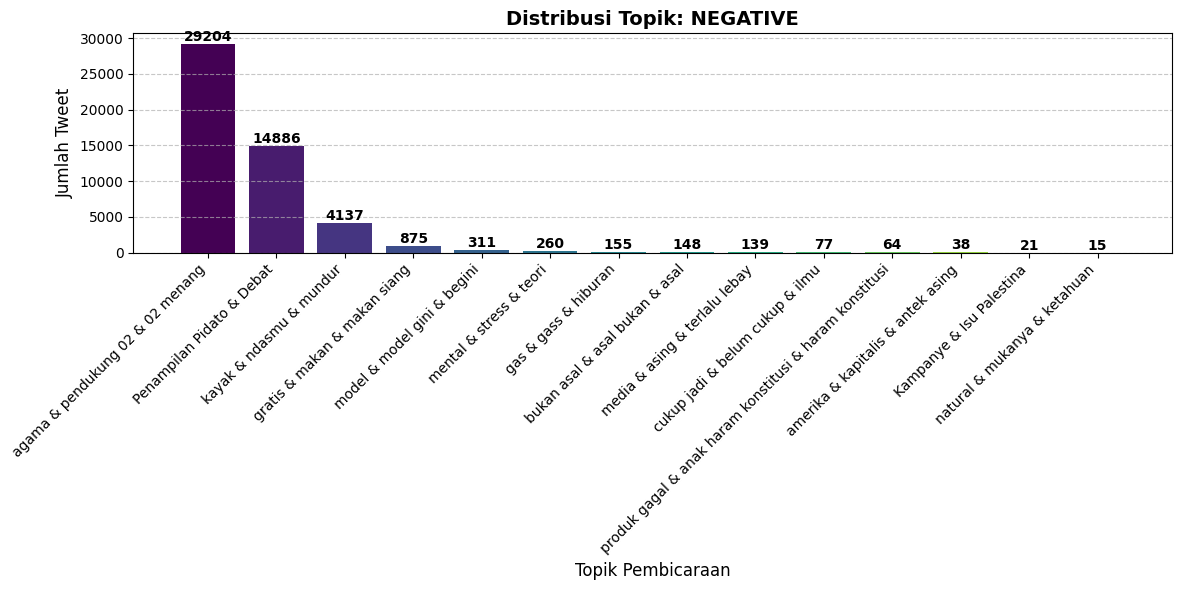

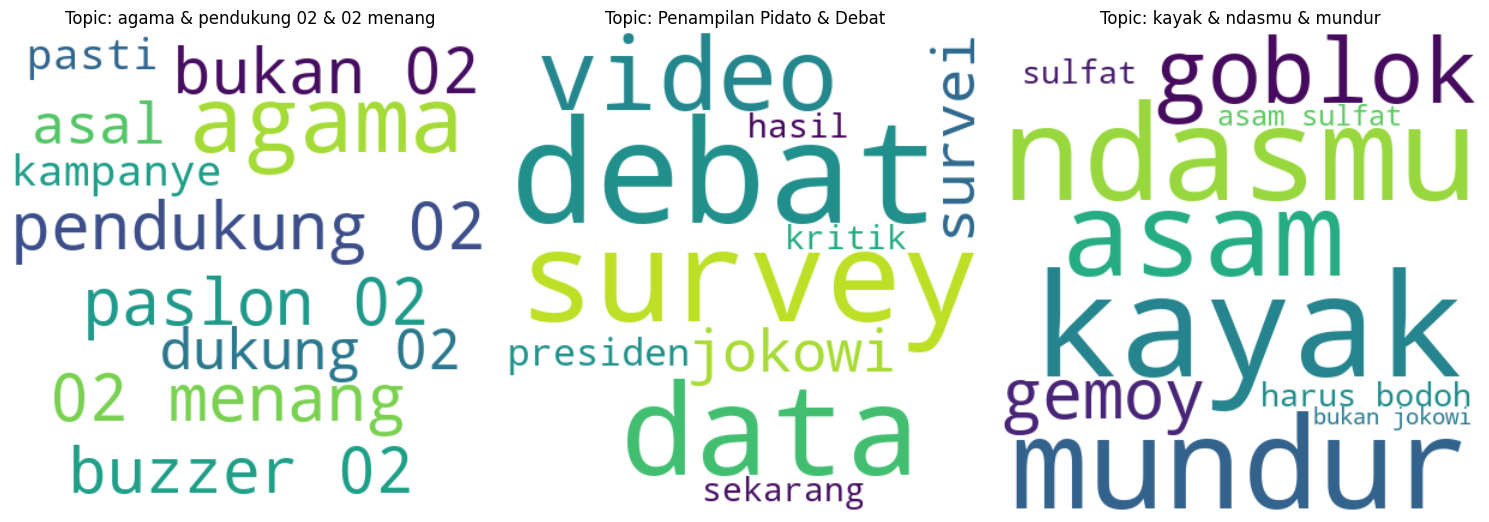


Kalimat Representatif untuk Setiap Topik (NEGATIVE):


,Topic ID,Label,Representative Sentence
0,0,agama & pendukung 02 & 02 menang,dulu lu koar2 2019gantipresiden lu maki2 jokow...
1,1,Penampilan Pidato & Debat,coba buka mata bahkan dari debat pertama prabo...
2,2,kayak & ndasmu & mundur,yang lebih tua harusnya tahu diri jalan saja s...
3,3,gratis & makan & makan siang,prabowo walah skrg 02 copas program paslon lai...
4,4,model & model gini & begini,ya tuhan model begini ngotot nyapres 3x akhirn...
5,5,mental & stress & teori,emang gini si mental pendukung 02
6,6,gas & gass & hiburan,ini literally masi pagi dan gw udha denger ora...
7,7,bukan asal & asal bukan & asal,asal bukan prabowo asal bukan prabowo asal buk...
8,8,media & asing & terlalu lebay,media pendukung 02 ini terlalu lebay judul ber...
9,9,cukup jadi & belum cukup & ilmu,viral gibran rakabuming nyadar diri kalau ilmu...


(<bertopic._bertopic.BERTopic at 0x2a37a505850>,
 [-1,
  -1,
  1,
  -1,
  1,
  1,
  1,
  1,
  0,
  3,
  -1,
  -1,
  0,
  1,
  1,
  -1,
  -1,
  -1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  -1,
  1,
  -1,
  1,
  -1,
  1,
  -1,
  -1,
  1,
  1,
  -1,
  4,
  1,
  -1,
  1,
  1,
  1,
  -1,
  1,
  1,
  1,
  -1,
  1,
  1,
  1,
  1,
  0,
  2,
  -1,
  1,
  2,
  0,
  0,
  1,
  -1,
  -1,
  -1,
  1,
  1,
  -1,
  0,
  -1,
  2,
  -1,
  0,
  2,
  1,
  1,
  1,
  0,
  2,
  1,
  -1,
  -1,
  1,
  2,
  0,
  2,
  -1,
  5,
  0,
  0,
  -1,
  -1,
  -1,
  1,
  1,
  2,
  2,
  -1,
  2,
  2,
  1,
  0,
  -1,
  2,
  0,
  -1,
  1,
  1,
  1,
  -1,
  1,
  1,
  1,
  -1,
  2,
  -1,
  0,
  -1,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  0,
  1,
  -1,
  0,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  2,
  -1,
  -1,
  1,
  1,
  1,
  0,
  2,
  2,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  0,
  2,
  2,
  1,
  -1,
  0,
  1,
  0,
  0,
  1,
  2,
  1,
  2,
  -1,
  0,
  -1,
  -1,
  0,
  1,
  1,
  1,
  1,
 

In [10]:
df_negative = df_02[df_02['predicted_label'] == 'NEGATIVE']
run_topic_modeling(df_negative, group_name='NEGATIVE')

2025-05-26 20:16:35,863 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 602/602 [03:48<00:00,  2.64it/s]
2025-05-26 20:20:24,191 - BERTopic - Embedding - Completed ✓
2025-05-26 20:20:24,193 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 20:20:37,098 - BERTopic - Dimensionality - Completed ✓
2025-05-26 20:20:37,100 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 20:24:11,738 - BERTopic - Cluster - Completed ✓
2025-05-26 20:24:11,739 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 20:24:12,667 - BERTopic - Representation - Completed ✓
2025-05-26 20:24:12,668 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 20:24:12,687 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 20:24:13,388 - BERTopic - Representation - Completed ✓
2025-05-26 20:24:13,391 - BERTopic - Topic reduction - Re


Topic Information for: NEUTRAL
   Topic  Count                                            Name  \
0     -1   6773                           -1_kalo_kubu_mas_lain   
1      0   4933            0_02 02_pendukung 02_02 menang_video   
2      1   3240           1_berita_putaran_satu putaran_pilpres   
3      2   2442            2_politik_wakil_calon_wakil presiden   
4      3    849         3_debat_debat cawapres_strategi_ekonomi   
5      4    206  4_presiden_jadi presiden_presiden jokowi_mobil   
6      5    205                 5_estate_food_makan_food estate   
7      6    144              6_program_lanjutkan_posting_kirain   
8      7    109                           7_gas_ok_jabar_gabung   
9      8    102                     8_viral_mojokerto_apk_video   

                                   CustomName  \
0                                     outlier   
1            02 02 & pendukung 02 & 02 menang   
2             berita & putaran & satu putaran   
3                     politik & wa

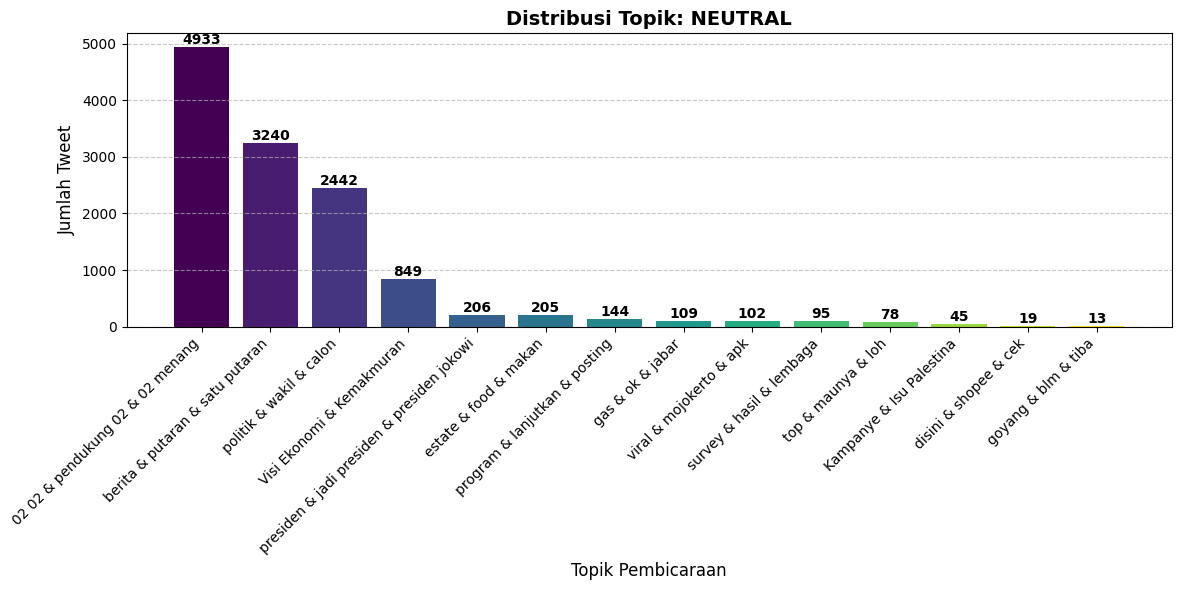

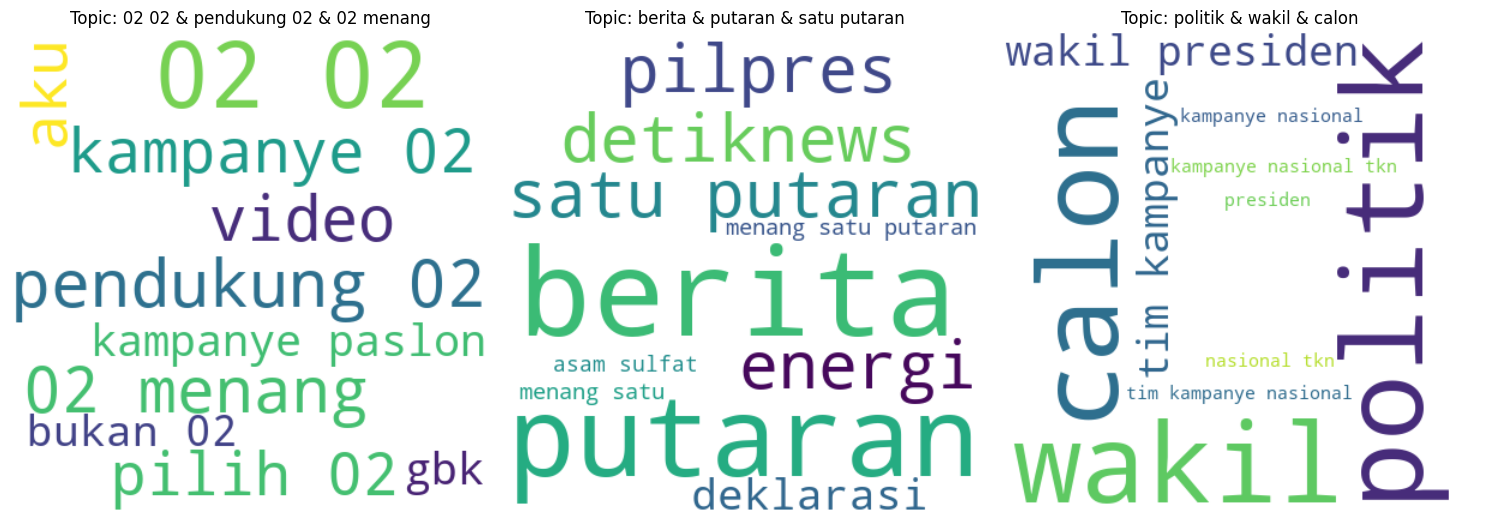


Kalimat Representatif untuk Setiap Topik (NEUTRAL):


,Topic ID,Label,Representative Sentence
0,0,02 02 & pendukung 02 & 02 menang,mungkin kalo programnya sarapan makan siang gr...
1,1,berita & putaran & satu putaran,hy bs geleng2 liat situasi ini syarat usia dig...
2,2,politik & wakil & calon,jakarta ketua tim kampanye nasional tkn prabow...
3,3,Visi Ekonomi & Kemakmuran,sewaktu debat cawapres 02 pernah menyampaikan ...
4,4,presiden & jadi presiden & presiden jokowi,gambaran 02 kalo jadi presiden
5,5,estate & food & makan,tkn prabowo gibran sebut program makan siang d...
6,6,program & lanjutkan & posting,dampingi prabowo subianto sapa warga sulsel ke...
7,7,gas & ok & jabar,kita gas yuk 02 satu putaran
8,8,viral & mojokerto & apk,viral apk prabowo gibran rakabuming terpasang ...
9,9,survey & hasil & lembaga,prabowo ini survey dapat di gorong gorong k


(<bertopic._bertopic.BERTopic at 0x2a37a773440>,
 [4,
  5,
  1,
  -1,
  2,
  1,
  0,
  -1,
  2,
  2,
  1,
  2,
  -1,
  1,
  1,
  1,
  1,
  2,
  1,
  1,
  1,
  1,
  1,
  2,
  1,
  0,
  1,
  1,
  1,
  2,
  -1,
  1,
  -1,
  6,
  6,
  6,
  -1,
  6,
  -1,
  -1,
  -1,
  2,
  1,
  -1,
  2,
  2,
  2,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  -1,
  1,
  -1,
  1,
  1,
  1,
  1,
  1,
  2,
  -1,
  2,
  -1,
  1,
  2,
  2,
  2,
  2,
  2,
  3,
  1,
  -1,
  2,
  2,
  2,
  1,
  -1,
  2,
  2,
  2,
  2,
  2,
  2,
  -1,
  -1,
  -1,
  -1,
  -1,
  2,
  2,
  1,
  1,
  1,
  -1,
  2,
  2,
  2,
  10,
  -1,
  2,
  -1,
  3,
  3,
  3,
  2,
  2,
  2,
  2,
  2,
  -1,
  2,
  -1,
  1,
  2,
  10,
  -1,
  2,
  2,
  2,
  2,
  2,
  -1,
  -1,
  -1,
  -1,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  -1,
  -1,
  -1,
  2,
  -1,
  2,
  2,
  2,
  -1,
  2,
  1,
  2,
  1,
  2,
  1,
  2,
  2,
  2,
  -1,
  2,
  2,
  1,
  2,
  2,
  2,
  -1,
  -1,
  -1,
  1,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2

In [11]:
df_neutral = df_02[df_02['predicted_label'] == 'NEUTRAL']
run_topic_modeling(df_neutral, group_name='NEUTRAL')